<a href="https://colab.research.google.com/github/demekeendalie/multi-emotion-classification/blob/main/label_co_occrance_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import drive

# This will prompt you for authorization
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data=pd.read_excel('/content/drive/My Drive/label.xlsx')

In [ ]:
print(data.head())

   sad  happy  anger  fear  disgust  surprise  contempt  neutral
0    1      0      1     0        1         0         0        0
1    0      0      0     1        0         0         0        0
2    0      0      0     1        0         0         0        0
3    1      0      0     1        0         0         0        0
4    0      0      1     1        0         0         1        0


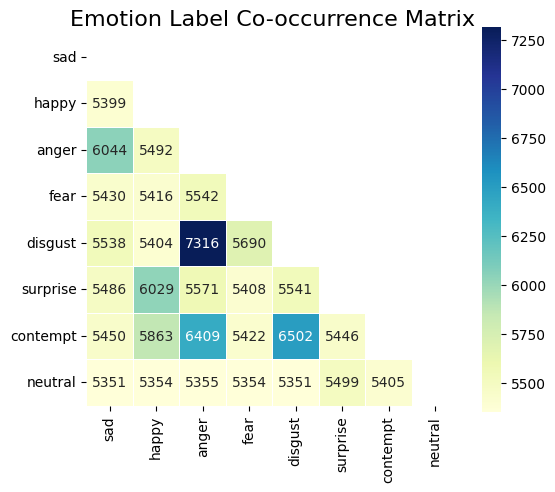

In [ ]:
co_occurrence_matrix = data.T.dot(data)

# 3. Plotting
plt.figure(figsize=(6, 5))

# We use a mask to hide the upper triangle for a cleaner look (optional)
mask = np.triu(np.ones_like(co_occurrence_matrix, dtype=bool))

sns.heatmap(
    co_occurrence_matrix,
    annot=True,            # Shows the actual numbers in the cells
    fmt='d',               # Formats numbers as integers
    cmap='YlGnBu',         # A clean blue-green-yellow color palette
    mask=mask,             # Hides the duplicate mirror image above the diagonal
    square=True,           # Makes the cells perfectly square
    linewidths=.5          # Adds a small gap between cells
)

plt.title('Emotion Label Co-occurrence Matrix', fontsize=16)
plt.show()

               Count  Percentage (%)
One Label      10348       46.972310
Two Labels      4288       19.464367
More than Two   6572       29.832047
Zero Labels      822        3.731276


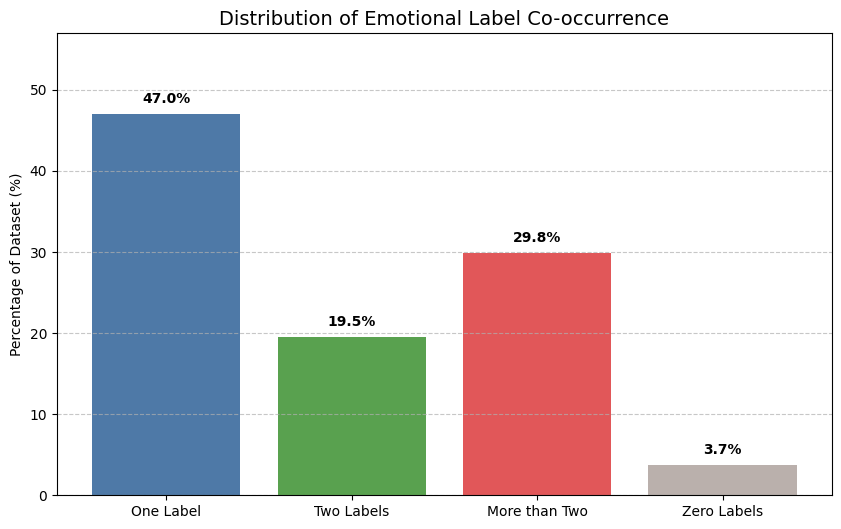

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

row_sums = data.sum(axis=1)

# 3. Categorize rows based on the number of labels
def categorize(count):
    if count == 1:
        return 'One Label'
    elif count == 2:
        return 'Two Labels'
    elif count > 2:
        return 'More than Two'
    else:
        return 'Zero Labels'

label_groups = row_sums.apply(categorize)

# 4. Calculate raw counts and percentages
counts = label_groups.value_counts()
percentages = (counts / len(data)) * 100

# Ensure specific order for the output
order = ['One Label', 'Two Labels', 'More than Two', 'Zero Labels']
results = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percentages
}).reindex(order).dropna()

print(results)

# 5. Plotting the results
plt.figure(figsize=(10, 6))
plot_data = results['Percentage (%)']
bars = plt.bar(plot_data.index, plot_data.values, color=['#4e79a7', '#59a14f', '#e15759', '#bab0ac'])

# Add percentage labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Emotional Label Co-occurrence', fontsize=14)
plt.ylabel('Percentage of Dataset (%)')
plt.ylim(0, max(plot_data.values) + 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()